# Radar tutorial 3 — compare sensors with each other and with MRMS

**What you'll learn:** how well each sensor agrees with the radar, with nearby official
gauges, and with NOAA's daily totals, for rain, mix and snow.

Metrics (`RU.scores`), over jointly valid samples:

| metric | meaning | units |
|---|---|---|
| **NRMSE** | RMSE / mean of the reference — the headline, comparable across storm sizes | – |
| rel. bias | Σ sensor / Σ reference − 1 | – |
| r | Pearson correlation | – |
| POD / FAR / CSI | wet-hour detection (wet = ≥ 0.1 mm/h, ≥ 1 mm for event totals) | – |

**Circularity warning.** MRMS Pass 2 is bias-corrected with rain gauges (including the
ASOS airports), and GHCN daily totals at the airports come from the same ASOS gauges.
So agreement between ASOS and either of them is partly built in. MRMS **radar-only**
QPE has seen no gauge: it is the independent yardstick, and every comparison below
reports it as well.

Three comparisons, from finest to most robust:
1. **hourly, sensor vs. MRMS** at the sensor's location;
2. **hourly, sensor vs. the nearest ASOS gauge** (≤ 5 km) — sensor to sensor;
3. **event totals vs. NOAA GHCN daily** — the manually checked water equivalent,
   the fairest reference in snow.

In [1]:
import sys, warnings
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
pd.set_option('display.width', 200, 'display.max_columns', 30)

REPO_ROOT = Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT / 'src'))
from fetch_data.mrms import MRMSClient, NYC, PRODUCTS, PRECIP_FLAG, event_accumulation
from analysis import radar_utils as RU

## §1. Load and merge all 15 events (≈ 4 min)

In [2]:
networks, cml, ghcn = RU.load_sensors(verbose=False)
events = RU.load_event_catalog()
merged = RU.merge_events(events, networks, cml)

  2026-02-22_snow         7,093 rows


  2026-01-25_snow         8,225 rows


  2025-12-26_snow         3,979 rows


  2024-02-17_snow         2,955 rows


  2024-02-13_snow         2,970 rows


...

  2024-03-09_mix         16,548 rows


  2025-02-15_mix         10,919 rows


  2025-12-19_mix          5,280 rows


  2025-02-09_mix          1,969 rows


  2024-01-06_mix          5,684 rows


## §2. Hourly: every sensor vs. MRMS

Radar is the reference here. Units: mean_ref / mean_est / rmse in mm h⁻¹. Groups with
fewer than 30 sensor-hours get NaN metrics.

In [3]:
cols = ['n_sensors', 'n', 'mean_ref', 'mean_est', 'rel_bias', 'rmse', 'nrmse', 'corr', 'pod', 'far', 'csi']
by_class = RU.compare_sensors(merged, by=('cls', 'network'))
by_class[cols].round(2)

n_sensors      n  mean_ref  mean_est  rel_bias  rmse  nrmse  corr   pod   far   csi
cls  network                                                                                     
mix  ASOS             5    843      0.58      0.61      0.06  0.48   0.83  0.95  0.91  0.19  0.75
     CML            120   4070      0.46      1.18      1.57  3.61   7.88  0.38  0.72  0.66  0.30
     Mesonet          4    860      0.62      0.65      0.05  0.44   0.71  0.97  0.84  0.12  0.75
     WU PWS          79  11935      0.64      0.57     -0.11  1.35   2.11  0.72  0.69  0.22  0.58
rain ASOS             5    928      1.27      1.37      0.07  0.99   0.77  0.96  0.91  0.15  0.78
     CML            120   4590      1.52      2.34      0.54  3.78   2.49  0.56  0.79  0.26  0.61
     Mesonet          4    928      1.48      1.55      0.05  0.75   0.51  0.98  0.86  0.11  0.78
     WU PWS          80  13378      1.38      1.35     -0.02  1.76   1.27  0.80  0.85  0.13  0.76
snow ASOS             5    504      0.74      0.60     -0.19  0.74   0.99  0.73  0.81  0.14  0.72
     CML            120   8860      0.96      1.79      0.87  5.00   5.23  0.19  0.70  0.33  0.52
     Mesonet          4    564      0.87      0.78     -0.10  0.62   0.72  0.85  0.86  0.10  0.78
     WU PWS          78   6518      0.86      0.12     -0.86  1.40   1.63  0.03  0.16  0.28  0.15

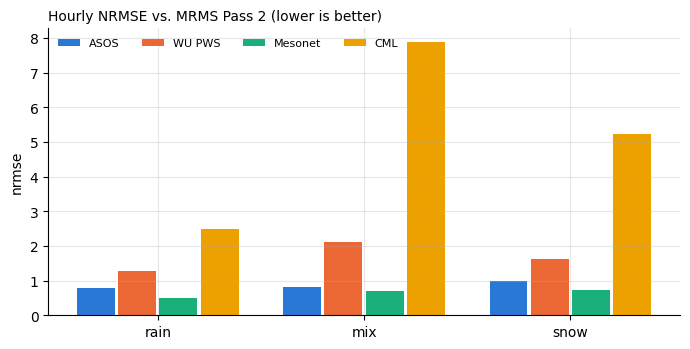

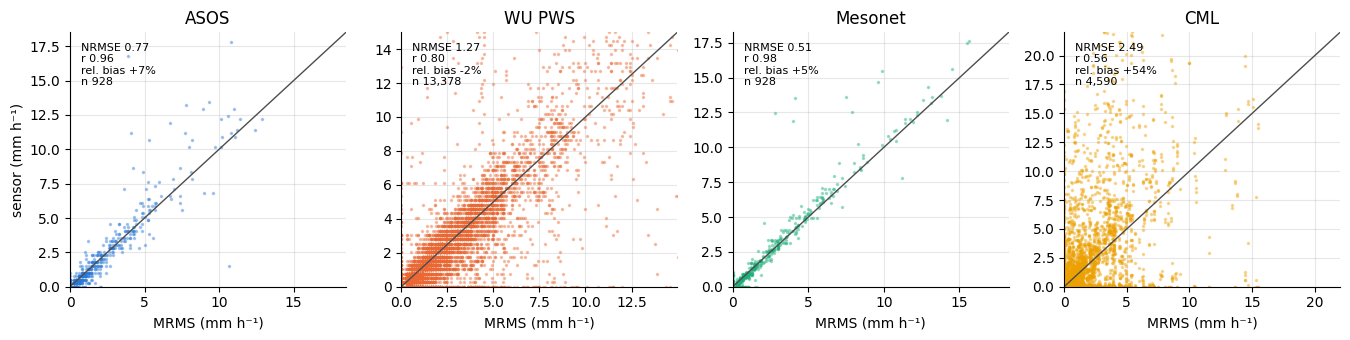

In [4]:
RU.plot_scores_by_class(by_class, 'nrmse', title='Hourly NRMSE vs. MRMS Pass 2 (lower is better)');
RU.plot_sensor_vs_radar(merged[merged.cls == 'rain']);

Same table against the **gauge-independent** radar-only QPE. The gap between the two
tables is how much of the agreement above came from the gauge correction.

In [5]:
by_class_ro = RU.compare_sensors(merged, by=('cls', 'network'), reference='radar_only_mm')
by_class_ro[cols].round(2)

n_sensors      n  mean_ref  mean_est  rel_bias  rmse  nrmse  corr   pod   far   csi
cls  network                                                                                     
mix  ASOS             5    843      0.44      0.61      0.40  0.94   2.15  0.82  0.86  0.16  0.75
     CML            120   4070      0.34      1.18      2.47  3.62  10.67  0.45  0.73  0.64  0.31
     Mesonet          4    860      0.49      0.65      0.33  0.96   1.95  0.85  0.78  0.11  0.71
     WU PWS          79  11935      0.48      0.57      0.18  1.49   3.12  0.62  0.66  0.20  0.57
rain ASOS             5    928      1.08      1.37      0.27  1.72   1.60  0.87  0.84  0.11  0.76
     CML            120   4590      1.15      2.34      1.04  4.07   3.54  0.50  0.78  0.22  0.64
     Mesonet          4    928      1.18      1.55      0.32  1.84   1.56  0.86  0.79  0.07  0.75
     WU PWS          80  13378      1.05      1.35      0.29  2.10   2.00  0.72  0.80  0.09  0.74
snow ASOS             5    504      0.62      0.60     -0.03  0.75   1.21  0.64  0.77  0.12  0.70
     CML            120   8860      0.78      1.79      1.28  4.95   6.33  0.28  0.70  0.31  0.53
     Mesonet          4    564      0.70      0.78      0.11  0.83   1.18  0.70  0.82  0.08  0.76
     WU PWS          78   6518      0.75      0.12     -0.84  1.20   1.60  0.02  0.15  0.25  0.15

## §3. Sensor to sensor: vs. the nearest ASOS gauge (≤ 5 km)

`MRMS` / `MRMS radar-only` here are the radar at the ASOS gauges themselves — the same
yardstick for the radar as for the other sensors.

In [6]:
pairs = RU.compare_to_reference(merged, by=('cls', 'network'))
pairs[['n_sensors', 'median_dist_km', 'n', 'rel_bias', 'nrmse', 'corr']].round(2)

n_sensors  median_dist_km     n  rel_bias  nrmse  corr
cls  network                                                                
mix  CML                      8            2.67     8       NaN    NaN   NaN
     MRMS                     5            0.00   843     -0.06   0.78  0.95
     MRMS radar-only          5            0.00   843     -0.29   1.53  0.82
     Mesonet                  1            1.33   159      0.14   0.76  0.98
     WU PWS                  13            3.61  1015      0.10   1.65  0.86
rain CML                      8            2.67     8       NaN    NaN   NaN
     MRMS                     5            0.00   928     -0.07   0.72  0.96
     MRMS radar-only          5            0.00   928     -0.21   1.26  0.87
     Mesonet                  1            1.33   175      0.06   0.56  0.97
     WU PWS                  13            3.61  1265     -0.02   0.96  0.89
snow CML                      8            2.67   352     -0.69   1.62  0.27
     MRMS                     5            0.00   504      0.24   1.23  0.73
     MRMS radar-only          5            0.00   504      0.03   1.24  0.64
     Mesonet                  1            1.33    97     -0.06   0.49  0.94
     WU PWS                  13            3.61   403     -0.55   1.85  0.12

## §4. Event totals vs. NOAA GHCN daily

For each GHCN station and event: GHCN precipitation over the event's local days vs. the
MRMS cell totals and the mean of each network's gauges within 5 km (units: mm). A NaN
means a sensor had a gap somewhere in the window (all hours are required).

In [7]:
totals = RU.event_totals_vs_ghcn(events, networks, ghcn)
display(totals.round(1).head(12))
tot_scores = RU.totals_scores(totals)
tot_scores[['n', 'mean_ref', 'mean_est', 'rel_bias', 'nrmse', 'corr']].round(2)

,event,cls,ghcn_station,ghcn_mm,MRMS,MRMS radar-only,ASOS,WU PWS,Mesonet
0,2026-02-22_snow,snow,USW00014732,50.3,51.9,45.1,NaN,NaN,NaN
1,2026-02-22_snow,snow,USW00014734,53.9,58.9,52.1,NaN,NaN,NaN
2,2026-02-22_snow,snow,USW00094728,48.0,51.0,46.9,NaN,NaN,45.1
3,2026-02-22_snow,snow,USW00094789,44.2,48.2,44.5,9.7,NaN,NaN
4,2026-01-25_snow,snow,USW00014732,32.5,34.3,19.9,NaN,0.0,NaN
5,2026-01-25_snow,snow,USW00014734,34.3,31.5,20.1,NaN,NaN,NaN
6,2026-01-25_snow,snow,USW00094728,46.2,33.9,20.5,NaN,NaN,39.0
7,2026-01-25_snow,snow,USW00094789,28.7,36.1,22.0,NaN,NaN,NaN
8,2025-12-26_snow,snow,USW00014732,10.7,11.7,8.8,NaN,0.0,NaN
9,2025-12-26_snow,snow,USW00014734,11.7,11.8,9.0,NaN,NaN,NaN


n  mean_ref  mean_est  rel_bias  nrmse  corr
cls  sensor                                                        
mix  MRMS             20     27.19     26.24     -0.04   0.12  0.96
     MRMS radar-only  20     27.19     20.44     -0.25   0.40  0.58
     ASOS              8     28.68     28.67     -0.00   0.01  1.00
     WU PWS           10     26.61     31.13      0.17   0.31  0.82
     Mesonet           5     26.14     29.36      0.12   0.23  0.99
rain MRMS             20     65.72     62.62     -0.05   0.15  0.79
     MRMS radar-only  20     65.72     50.65     -0.23   0.33  0.41
     ASOS              7     70.66     70.61     -0.00   0.00  1.00
     WU PWS           10     69.84     77.48      0.11   0.20  0.28
     Mesonet           5     70.96     78.61      0.11   0.15  0.76
snow MRMS             20     23.97     24.34      0.02   0.17  0.97
     MRMS radar-only  20     23.97     20.19     -0.16   0.33  0.91
     ASOS              5     15.00      8.03     -0.46   1.03  0.46
     WU PWS            6     14.92      4.66     -0.69   0.98  0.03
     Mesonet           5     26.18     23.78     -0.09   0.13  1.00

## §5. Precipitation type: ASOS present weather vs. MRMS PrecipFlag

Counts of 10-min station bins with a wet ASOS code, by the radar's surface type in
the station's cell.

In [8]:
RU.phase_agreement(networks['ASOS'], events)

mrms,none,rain,snow,All
asos,,,,
mix,819,311,48,1178
rain,862,3002,289,4153
snow,586,443,1061,2090
All,2267,3756,1398,7421


## §6. CML: which attenuation baseline?

Same hourly comparison for the four baseline methods in the attenuation file, rain
events only (the power law is for liquid rain).

In [9]:
rain = events[events.cls == 'rain']
rows = []
for b in ['att_static', 'att_rollq', 'att_drymed', 'att_ewma']:
    m = pd.concat([RU.merge_event(ev, {}, cml, baseline=b) for ev in rain.itertuples()])
    rows.append({'baseline': b, **RU.scores(m.sensor_mm, m.radar_mm)})
pd.DataFrame(rows).set_index('baseline')[['n', 'rel_bias', 'rmse', 'nrmse', 'corr', 'csi']].round(2)

,n,rel_bias,rmse,nrmse,corr,csi
baseline,,,,,,
att_static,4656,0.52,3.98,2.62,0.52,0.61
att_rollq,4664,1.08,4.79,3.15,0.49,0.56
att_drymed,4590,0.54,3.78,2.49,0.56,0.61
att_ewma,4656,0.74,4.13,2.72,0.52,0.60


## Findings (15 events, 2023-11 → 2026-02)

Numbers from the run above; rain / mix / snow = the 5 events of each class.

* **Rain:** the gauges agree with MRMS Pass 2 at the hourly scale — NRMSE 0.51 (Mesonet),
  0.77 (ASOS), 1.27 (WU PWS), r ≥ 0.80. Against the gauge-independent radar-only QPE the
  gauges' NRMSE rises to ~1.6–2.0 and radar-only runs ~20–30 % low: most of the Pass-2
  agreement comes from its gauge correction. Two gauges 1.3 km apart (Mesonet vs. ASOS)
  reach NRMSE 0.56 — the practical floor for point comparisons.
* **Snow:** unheated WU PWS gauges catch ~14 % of the radar's water (rel. bias −86 %);
  ASOS 1-min totals are −46 % vs. NOAA daily (outages + under-catch); the Mesonet
  weighing gauges and MRMS Pass 2 match NOAA event totals within ~10 % and ~2 %.
  For snow, use MRMS Pass 2 or the Mesonet, not PWS.
* **CML:** the ITU rain power law over-estimates (rel. bias +54 % in rain, NRMSE 2.5,
  r 0.56) and far more in snow/mix, where wet-snow attenuation is not rain. Of the four
  attenuation baselines, `att_drymed` (dry-hour daily median) scores best; wet-antenna
  correction is the obvious next step.
* **Precip type:** where ASOS reports snow, MRMS PrecipFlag says snow in 51 % of
  station-bins, rain in 21 %, none in 28 %; for ASOS rain, 72 % rain. MRMS has no mixed
  class, and light precipitation often falls below its detection ("none").
